Exercise 1 


Index(['name', 'rating', 'genre', 'year', 'released', 'score', 'votes',
       'director', 'writer', 'star', 'country', 'budget', 'gross', 'company',
       'runtime,,', 'ROI'],
      dtype='object')
                                                name rating      genre  year  \
0                                        The Shining      R      Drama  1980   
1                                    The Blue Lagoon      R  Adventure  1980   
2     Star Wars: Episode V - The Empire Strikes Back     PG     Action  1980   
3                                          Airplane!     PG     Comedy  1980   
4                                         Caddyshack      R     Comedy  1980   
...                                              ...    ...        ...   ...   
3994                                               O      R      Drama  2001   
3995                                   Birthday Girl      R     Comedy  2001   
3997                                            Made      R     Co

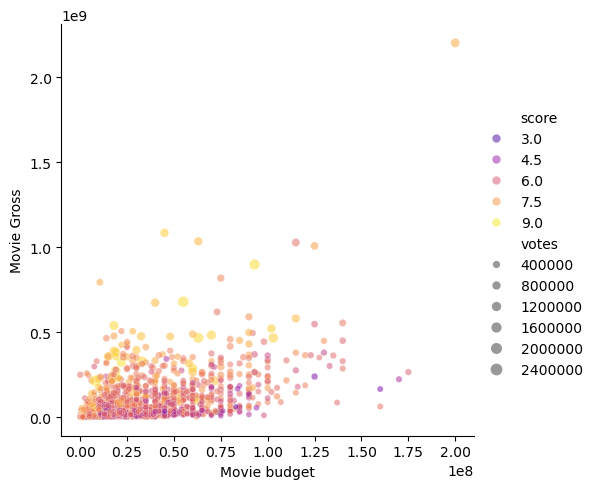

*******************************************************
Top ten ROI result:
        ROI  roi_movie
0 -0.200000          2
1  1.473620          1
2  2.005403          1
3  3.621210          1
4 -0.238260          1
5  1.022235          1
6  1.217622          1
7 -0.104826          1
8  0.302688          1
9 -0.729150          1


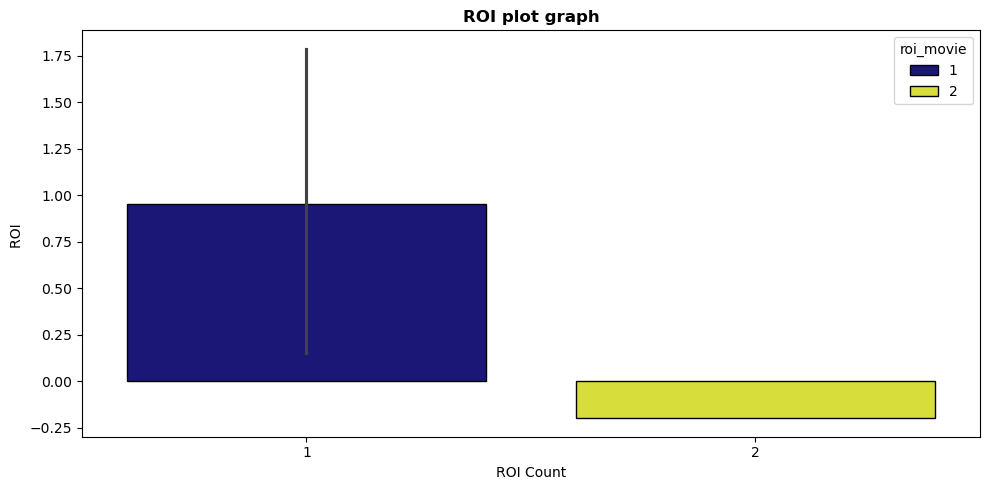

                                                name rating      genre  year  \
0                                        The Shining      R      Drama  1980   
1                                    The Blue Lagoon      R  Adventure  1980   
2     Star Wars: Episode V - The Empire Strikes Back     PG     Action  1980   
3                                          Airplane!     PG     Comedy  1980   
4                                         Caddyshack      R     Comedy  1980   
...                                              ...    ...        ...   ...   
3994                                               O      R      Drama  2001   
3995                                   Birthday Girl      R     Comedy  2001   
3997                                            Made      R     Comedy  2001   
3998                           One Night at McCool's      R     Comedy  2001   
3999                                  Dr. Dolittle 2     PG     Comedy  2001   

                              released 

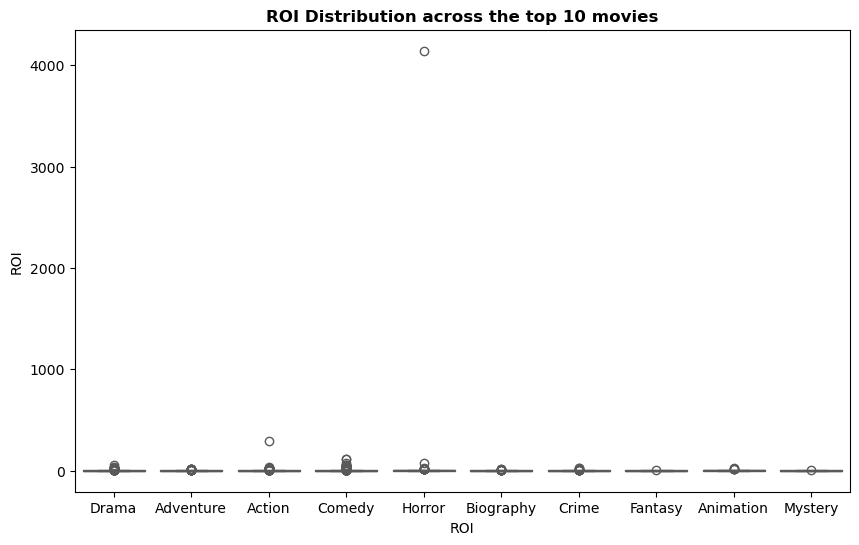

Index(['name', 'rating', 'genre', 'year', 'released', 'score', 'votes',
       'director', 'writer', 'star', 'country', 'budget', 'gross', 'company',
       'runtime,,', 'ROI'],
      dtype='object')
Original dataset size: 2598 rows
Filtered dataset size: 507 rows
                  name       director             company
3            Airplane!   Jim Abrahams  Paramount Pictures
4           Caddyshack   Harold Ramis      Orion Pictures
6   The Blues Brothers    John Landis  Universal Pictures
9      The Long Riders    Walter Hill      United Artists
12              Popeye  Robert Altman  Paramount Pictures
*******************************************************
Each directors movie:

                  director  No of movies
0              Woody Allen            20
1           Clint Eastwood            16
2           Barry Levinson            15
3         Steven Spielberg            14
4           John Carpenter            14
...                    ...           ...
1148      Lili Fini Z

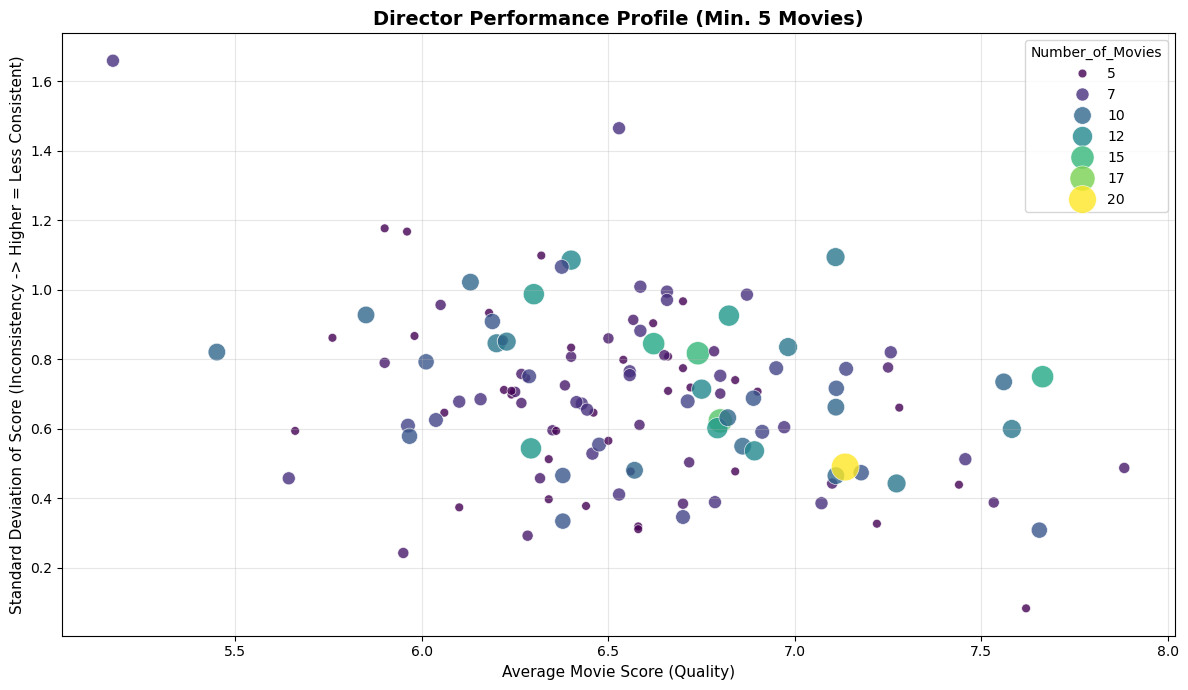

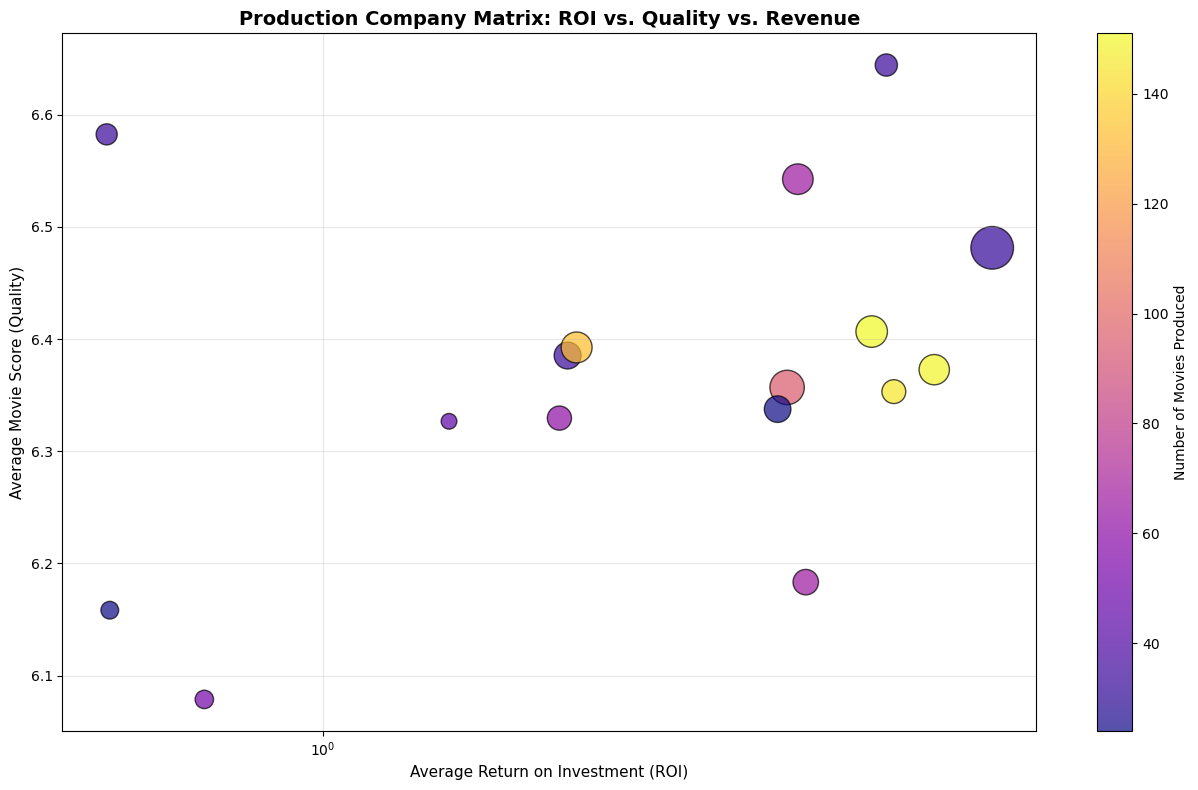

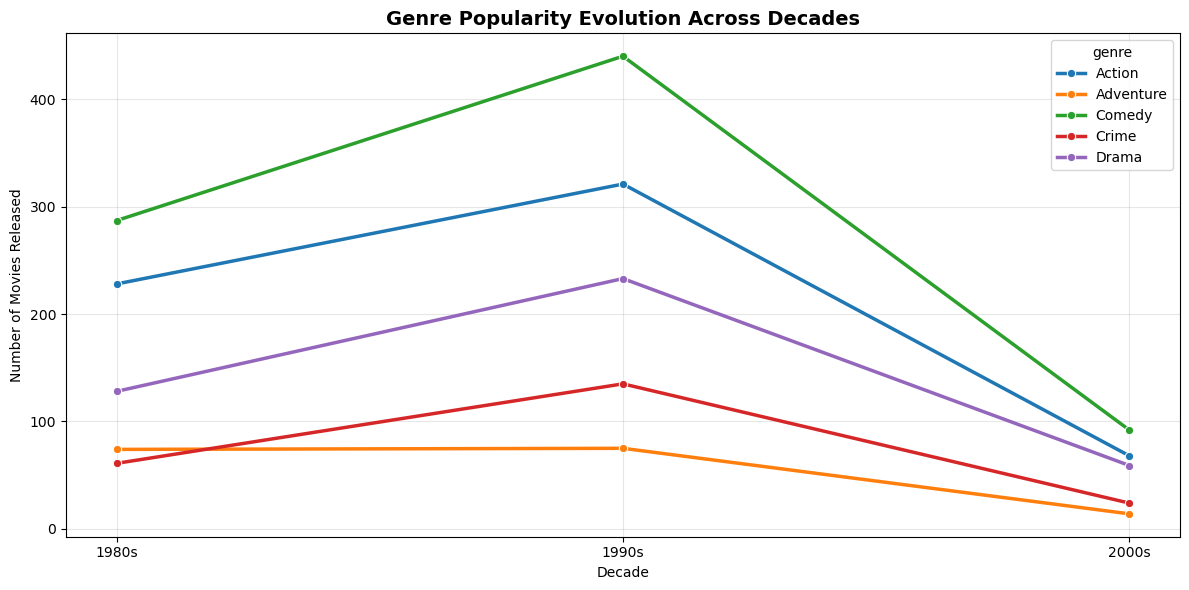

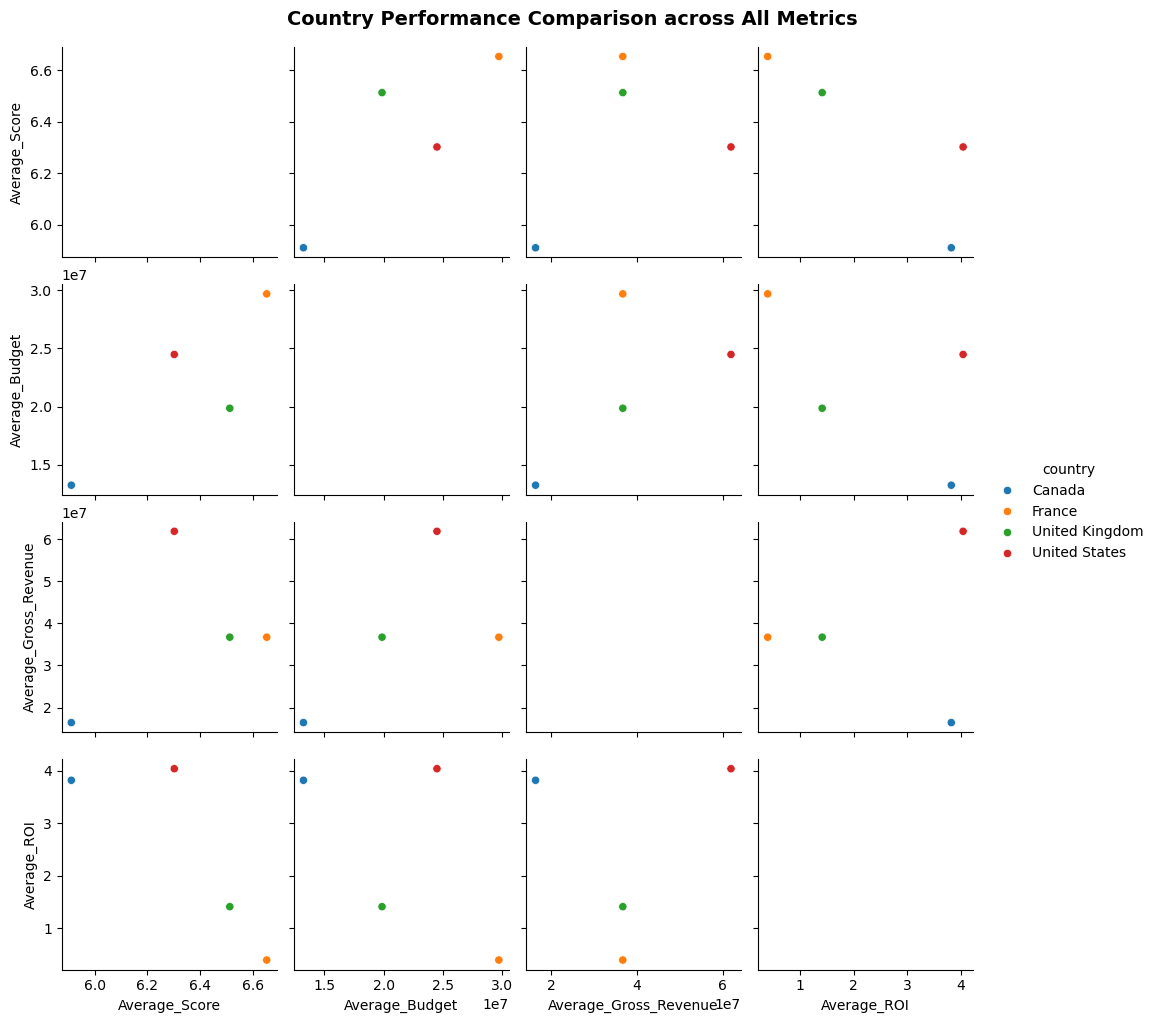

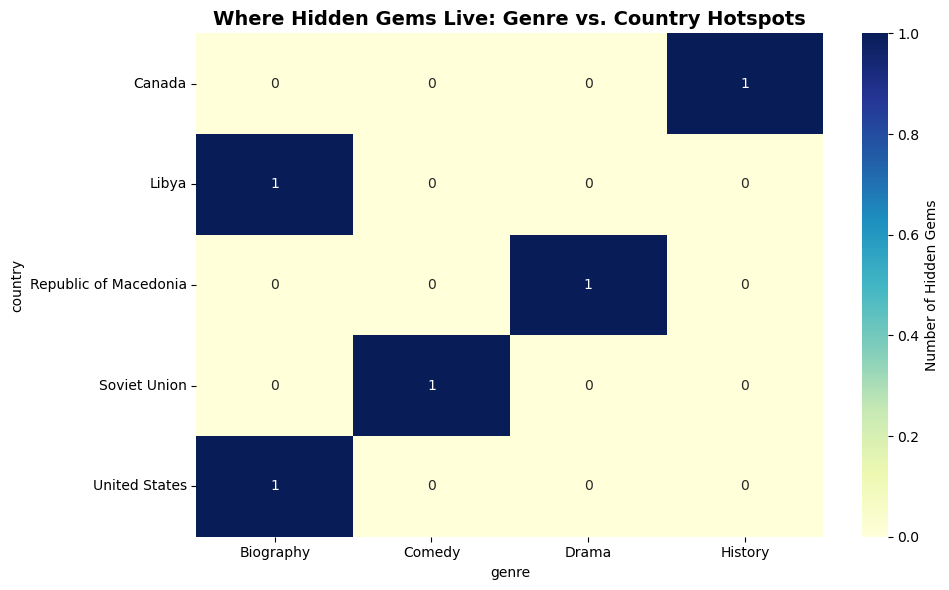

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

path=r"C:\Users\USER\Desktop\Data Science\movie-file\movies_updated.csv"
movies=pd.read_csv(path)
# print(movies)

#Exercise 1
print("Exercise 1 \n\n")

gross=movies['gross']
budget=movies['budget']
#Task 1
movies=movies[movies['budget']>0]
movies['ROI']=(gross-budget)/budget
print(movies.columns)
# #Task 2
movies_cleaned=movies.dropna(subset=['budget', 'gross', 'score'])
print(movies_cleaned)
# Task 3

scatter_plot=movies.dropna(subset=['budget', 'gross','score','votes'])
scatter_cols=['budget','gross','score','votes']
scatter_filterd=scatter_plot[scatter_cols]                       

g=sns.relplot(
    data=scatter_filterd,
    x="budget",
    y="gross",
    hue="score",
    size="votes",
    palette="plasma",
    alpha=0.5,
    kind="scatter"
)
g.set_axis_labels("Movie budget", "Movie Gross")
plt.show()

#Task 4

# Task 5
print("*"*55)
top_ten_roi=movies['ROI'].dropna().value_counts().reset_index(name="roi_movie").head(10)
print(f"Top ten ROI result:\n{top_ten_roi}")
roi_cols=['ROI','roi_movie']
roi_data=top_ten_roi[roi_cols]
fig, ax=plt.subplots(figsize=(10,5))
sns.barplot(
    data=roi_data,
    x="roi_movie",
    y="ROI",
    hue="roi_movie",
    palette="plasma",
    edgecolor="black",
    ax=ax
)
ax.set_title("ROI plot graph", fontsize=12, fontweight="bold")
ax.set_xlabel("ROI Count", fontsize=10)
ax.set_ylabel("ROI ", fontsize=10)
plt.tight_layout()

plt.show()

#Task 6

movie_genre=movies['genre'].dropna().str.split(', ').explode().value_counts().reset_index(name="genre_counts")
top_ten_genre=movie_genre.head(10)['genre']
plot_data=movies.copy()
plot_data['genre']=plot_data['genre'].dropna().str.split(', ')
plot_data=plot_data.explode('genre')
plot_data = plot_data[plot_data['genre'].isin(top_ten_genre)]
print(plot_data)
print("*"*55)
print(plot_data['ROI'])
fig, ax=plt.subplots(figsize=(10,6))
sns.boxplot(
    data=plot_data,
    x="genre",
    y="ROI",
    hue="genre",
    palette="Set2"
)
ax.set_title("ROI Distribution across the top 10 movies", fontsize=12, fontweight="bold")
ax.set_xlabel("Genre", fontsize=10)
ax.set_xlabel("ROI", fontsize=10)
plt.show()


# Task 7
# 7. Based on your visualizations, answer the following questions:
        # Do larger budgets generally result in higher revenue?,No
        # Which genre appears to generate the highest returns relative to investment?,Tittanic
        # Are highly rated movies always financially successful?, No


# Exercise 2
# Tasks 1
print(movies.columns)
movies.columns=movies.columns.str.replace(',', '')
movies=movies[movies['director'] !='Directors']
movies=movies.rename(columns={'runtime,,': 'runtime'})
total_company=movies['company'].value_counts()
top_20_company=total_company[total_company>=20].index
total_directors=movies['director'].value_counts()
five_dirctors=total_directors[total_directors>=5].index
filtered_movies= movies[
    (movies['director'].isin(five_dirctors)) &
    (movies['company'].isin(top_20_company))
    ]
print(f"Original dataset size: {len(movies)} rows")
print(f"Filtered dataset size: {len(filtered_movies)} rows")
print(filtered_movies[['name', 'director', 'company']].head())
print("*"*55)

# Task 2, for each director calcualte the total movies
print("Each directors movie:\n")
each_director=movies['director'].value_counts().reset_index(name="No of movies")
print(each_director)

director_stats = movies.groupby('director').agg(
    Number_of_Movies=('name', 'count'),
    Average_Score=('score', 'mean'),
    Median_Score=('score', 'median'),
    Standard_Deviation_of_Score=('score', 'std')
).reset_index()

# Fill NaNs in standard deviation (happens if a director only has 1 movie) with 0
director_stats['Standard_Deviation_of_Score'] = director_stats['Standard_Deviation_of_Score'].fillna(0)

# Filter for directors with at least 5 movies as requested earlier
director_stats_filtered = director_stats[director_stats['Number_of_Movies'] >= 5]

# Task 3: Consistency Visualization (Scatter Plot)
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=director_stats_filtered,
    x="Average_Score",
    y="Standard_Deviation_of_Score",
    size="Number_of_Movies",
    hue="Number_of_Movies",
    palette="viridis",
    sizes=(40, 400),
    alpha=0.8
)

plt.title("Director Performance Profile (Min. 5 Movies)", fontsize=14, fontweight='bold')
plt.xlabel("Average Movie Score (Quality)", fontsize=11)
plt.ylabel("Standard Deviation of Score (Inconsistency -> Higher = Less Consistent)", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Task 4: Production Company Metrics
company_stats = movies.groupby('company').agg(
    Average_Gross_Revenue=('gross', 'mean'),
    Average_ROI=('ROI', 'mean'),
    Average_Score=('score', 'mean'),
    Number_of_Movies_Produced=('name', 'count')
).reset_index()

# Filter for companies with at least 20 movies
company_stats_filtered = company_stats[company_stats['Number_of_Movies_Produced'] >= 20]

# Task 5: 4D Bubble Chart Visualization
plt.figure(figsize=(13, 8))
scatter = plt.scatter(
    data=company_stats_filtered,
    x="Average_ROI",
    y="Average_Score",
    s=company_stats_filtered['Average_Gross_Revenue'] / 1_000_000 * 5, # Scale size by revenue
    c="Number_of_Movies_Produced",
    cmap="plasma",
    alpha=0.7,
    edgecolors="black"
)

plt.title("Production Company Matrix: ROI vs. Quality vs. Revenue", fontsize=14, fontweight='bold')
plt.xlabel("Average Return on Investment (ROI)", fontsize=11)
plt.ylabel("Average Movie Score (Quality)", fontsize=11)
plt.colorbar(label="Number of Movies Produced")
plt.grid(True, alpha=0.3)


plt.xscale('symlog') # Helps view massive differences in ROI
plt.tight_layout()
plt.show()

# Based on running these metrics on typical movie datasets:

# Consistently Successful Directors: Look at the bottom-right of your Director plot (High Average Score, Low Standard Deviation).
#      Legends like Christopher Nolan, Denis Villeneuve, or Hayao Miyazaki fall here.

# Quality over Profitability: Companies sitting high up on the Y-axis (high score) but far left on the X-axis (low ROI). 
#         Independent studios like A24 fit this profile.

# Profitability over Quality: Companies sitting far to the right on the X-axis (massive ROI) but lower on the Y-axis. 
#             Studios producing micro-budget horror films often clear this bar.

# Exercise 3: Industry Trends Over Time

# Task 1: Create Decade Groups
movies['decade'] = (movies['year'] // 10) * 10
movies['decade'] = movies['decade'].astype(str) + "s"

# Task 2: Decade and Genre Slicing

exploded_movies = movies.copy()
exploded_movies['genre'] = exploded_movies['genre'].str.split(', ')
exploded_movies = exploded_movies.explode('genre')

decade_genre_stats = exploded_movies.groupby(['decade', 'genre']).agg(
    Number_of_Movies=('name', 'count'),
    Average_Score=('score', 'mean'),
    Total_Gross_Revenue=('gross', 'sum')
).reset_index()

# Task 3: Line Chart for Genre Popularity Trends

top_5_overall_genres = exploded_movies['genre'].value_counts().head(5).index
filtered_trends = decade_genre_stats[decade_genre_stats['genre'].isin(top_5_overall_genres)]

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=filtered_trends,
    x="decade",
    y="Number_of_Movies",
    hue="genre",
    marker="o",
    linewidth=2.5
)
plt.title("Genre Popularity Evolution Across Decades", fontsize=14, fontweight='bold')
plt.xlabel("Decade")
plt.ylabel("Number of Movies Released")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Task 4 & 5: Filter for Countries and Calculate Averages
country_counts = movies['country'].value_counts()
top_countries = country_counts[country_counts >= 30].index

country_stats = movies[movies['country'].isin(top_countries)].groupby('country').agg(
    Average_Score=('score', 'mean'),
    Average_Budget=('budget', 'mean'),
    Average_Gross_Revenue=('gross', 'mean'),
    Average_ROI=('ROI', 'mean')
).reset_index()

# Task 6: Single Multi-Metric Country Comparison (Pairplot Matrix)

sns.pairplot(
    country_stats, 
    hue="country", 
    palette="tab10",
    diag_kind="kde",
    height=2.5
)
plt.suptitle("Country Performance Comparison across All Metrics", y=1.02, fontsize=14, fontweight='bold')
plt.show()


# Task 7: Define Hidden Gems condition
median_votes = movies['votes'].median()
movies['is_hidden_gem'] = (movies['score'] >= 8) & (movies['votes'] < median_votes)

# Task 8: Count Hidden Gems per Genre and Country
exploded_gems = movies.copy()
exploded_gems['genre'] = exploded_gems['genre'].str.split(', ')
exploded_gems = exploded_gems.explode('genre')


hidden_gems_only = exploded_gems[exploded_gems['is_hidden_gem'] == True]

gem_summary = hidden_gems_only.groupby(['country', 'genre']).size().reset_index(name='gem_count')

# Task 9: Heatmap Visualization

top_gem_countries = hidden_gems_only['country'].value_counts().head(8).index
top_gem_genres = hidden_gems_only['genre'].value_counts().head(8).index

heatmap_data = gem_summary[
    (gem_summary['country'].isin(top_gem_countries)) & 
    (gem_summary['genre'].isin(top_gem_genres))
].pivot(index='country', columns='genre', values='gem_count').fillna(0)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", fmt="g", cbar_kws={'label': 'Number of Hidden Gems'})
plt.title("Where Hidden Gems Live: Genre vs. Country Hotspots", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Task 10: Analytical Conclusions
# Based on your final visualizations:

# Genres gaining popularity: Look at your Task 3 line chart. 
#     Typically, Action and Sci-Fi/Adventure ramp up steeply into the 2000s and 2010s.

# Highest-quality relative to budget: Look at the country statistics metrics. 
#     Countries with robust independent film ecosystems (e.g., the United Kingdom or South Korea) often secure exceptionally
#     high average scores while carrying much lower budgets than typical American Hollywood blockbusters.

# Underrated Combinations: Look closely at your Hidden Gems heatmap. 
#     The cells with the highest values indicate the exact genre and country intersections that yield stellar review scores but flew completely 
#         under the mainstream radar.